In [16]:
# Cell 1 — Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Import xong")

✅ Import xong


In [ ]:
# Ép kiểu dữ liệu nhỏ hơn khi đọc
transaction = pd.read_csv(
    r'D:\fraud_detection\data\train_transaction.csv',
    low_memory=True,
    dtype={
        'TransactionID': 'int32',
        'isFraud':       'int8',
        'TransactionAmt':'float32',
        'ProductCD':     'category',
        'card4':         'category',
        'card6':         'category',
        'P_emaildomain': 'category',
        'R_emaildomain': 'category',
    }
)

identity = pd.read_csv(
    r'D:\fraud_detection\data\train_identity.csv',
    low_memory=True,
    dtype={
        'TransactionID': 'int32',
        'DeviceType':    'category',
    }
)

print("TRANSACTION:", transaction.shape)
print("IDENTITY   :", identity.shape)
print(f"RAM dùng: {transaction.memory_usage(deep=True).sum() / 1e6:.1f} MB")

In [ ]:
# Cell 3 — Xem sơ bộ
print("--- 5 dòng đầu TRANSACTION ---")
display(transaction.head())

print("--- 5 dòng đầu IDENTITY ---")
display(identity.head())

--- 5 dòng đầu TRANSACTION ---


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


--- 5 dòng đầu IDENTITY ---


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [ ]:
# Cell 4 — Đếm nhãn
label_counts = transaction['isFraud'].value_counts()
label_pct    = transaction['isFraud'].value_counts(normalize=True) * 100

print("=== PHÂN PHỐI NHÃN ===")
print(f"Không gian lận (0): {label_counts[0]:,}  ({label_pct[0]:.2f}%)")
print(f"Gian lận       (1): {label_counts[1]:,}  ({label_pct[1]:.2f}%)")

=== PHÂN PHỐI NHÃN ===
Không gian lận (0): 569,877  (96.50%)
Gian lận       (1): 20,663  (3.50%)


In [ ]:
# Cell 6 — Phân nhóm features
feature_groups = {
    'Transaction Amount': ['TransactionAmt', 'ProductCD'],
    'Card Info':          [c for c in transaction.columns if c.startswith('card')],
    'Address':            [c for c in transaction.columns if c.startswith('addr')],
    'Email Domain':       [c for c in transaction.columns if 'emaildomain' in c],
    'Count (C)':          [c for c in transaction.columns if c.startswith('C') and c[1:].isdigit()],
    'Delta Time (D)':     [c for c in transaction.columns if c.startswith('D') and c[1:].isdigit()],
    'Match (M)':          [c for c in transaction.columns if c.startswith('M') and c[1:].isdigit()],
    'Vesta (V)':          [c for c in transaction.columns if c.startswith('V') and c[1:].isdigit()],
    'Device (Identity)':  [c for c in identity.columns  if 'Device' in c],
    'ID Features':        [c for c in identity.columns  if c.startswith('id_')],
}

print(f"{'Nhóm':<25} {'Số features':>12}  Ví dụ")
print("-" * 60)
for grp, cols in feature_groups.items():
    examples = ', '.join(cols[:3])
    if len(cols) > 3: examples += '...'
    print(f"{grp:<25} {len(cols):>12}  {examples}")

Nhóm                       Số features  Ví dụ
------------------------------------------------------------
Transaction Amount                   2  TransactionAmt, ProductCD
Card Info                            6  card1, card2, card3...
Address                              2  addr1, addr2
Email Domain                         2  P_emaildomain, R_emaildomain
Count (C)                           14  C1, C2, C3...
Delta Time (D)                      15  D1, D2, D3...
Match (M)                            9  M1, M2, M3...
Vesta (V)                          339  V1, V2, V3...
Device (Identity)                    2  DeviceType, DeviceInfo
ID Features                         38  id_01, id_02, id_03...


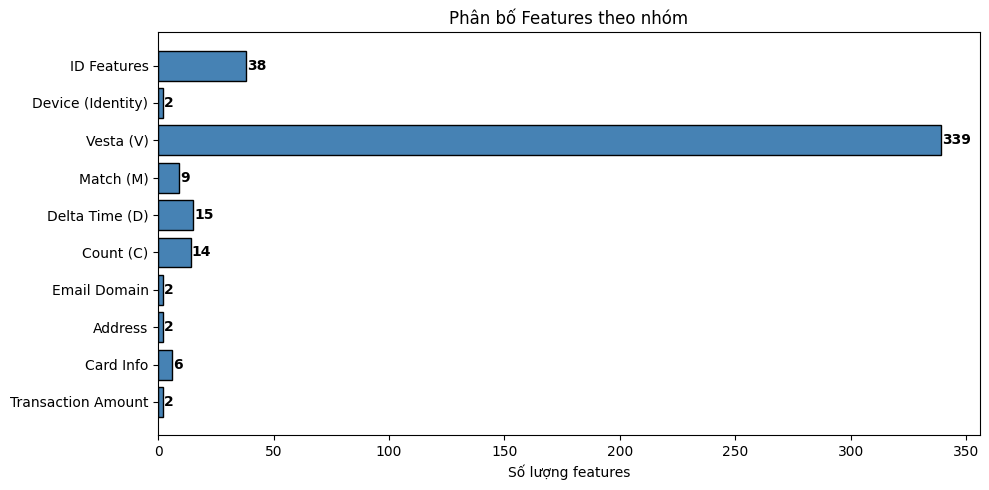

In [ ]:
# Cell 7 — Vẽ biểu đồ số lượng features theo nhóm
groups_count = {k: len(v) for k, v in feature_groups.items()}
plt.figure(figsize=(10, 5))
bars = plt.barh(list(groups_count.keys()), list(groups_count.values()),
                color='steelblue', edgecolor='black')
plt.xlabel('Số lượng features')
plt.title('Phân bố Features theo nhóm')
for bar, val in zip(bars, groups_count.values()):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_groups.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 8 — Tính missing rate
def missing_summary(df, name):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    result = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
    result = result[result['missing_count'] > 0].sort_values('missing_pct', ascending=False)

    print(f"\n{'='*40}")
    print(f" MISSING SUMMARY — {name}")
    print(f"{'='*40}")
    print(f"Tổng cột có missing : {len(result)} / {df.shape[1]}")
    print(f"Missing > 90%       : {(result['missing_pct'] > 90).sum()} cột")
    print(f"Missing 50–90%      : {((result['missing_pct'].between(50,90))).sum()} cột")
    print(f"Missing < 50%       : {(result['missing_pct'] < 50).sum()} cột")
    return result

miss_trans = missing_summary(transaction, 'TRANSACTION')
miss_iden  = missing_summary(identity,    'IDENTITY')


 MISSING SUMMARY — TRANSACTION
Tổng cột có missing : 374 / 394
Missing > 90%       : 2 cột
Missing 50–90%      : 172 cột
Missing < 50%       : 200 cột

 MISSING SUMMARY — IDENTITY
Tổng cột có missing : 38 / 41
Missing > 90%       : 9 cột
Missing 50–90%      : 3 cột
Missing < 50%       : 26 cột


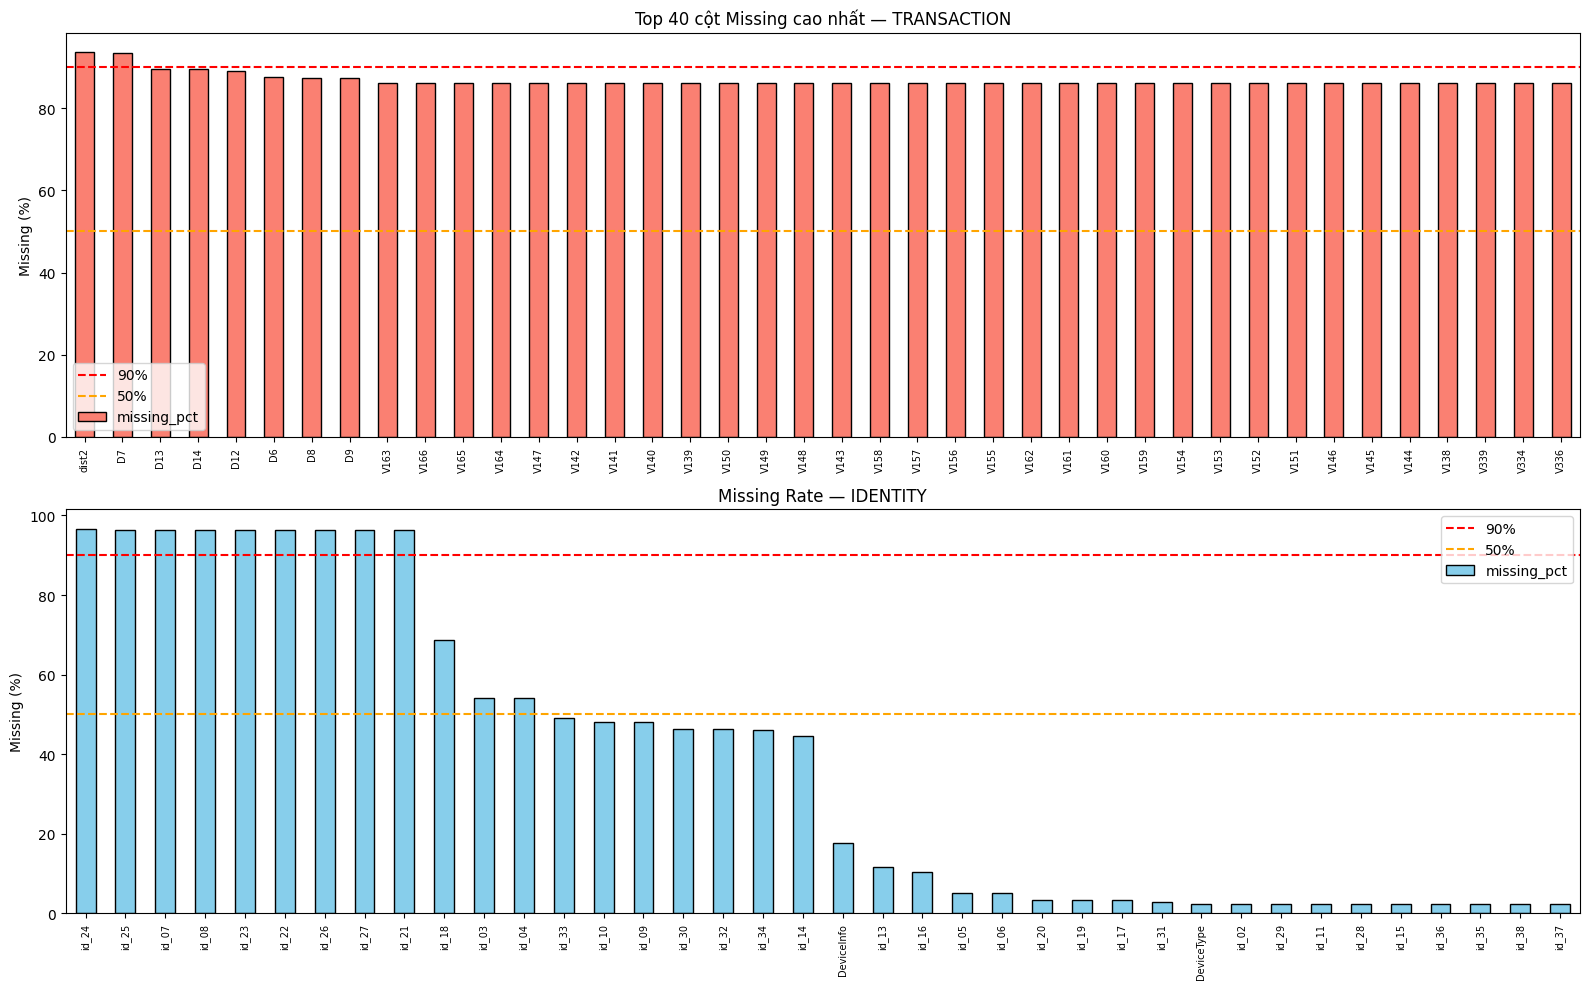

In [ ]:
# Cell 9 — Vẽ biểu đồ missing rate
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Transaction — top 40 cột missing cao nhất
miss_trans.head(40)['missing_pct'].plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Top 40 cột Missing cao nhất — TRANSACTION', fontsize=12)
axes[0].set_ylabel('Missing (%)')
axes[0].axhline(y=90, color='red',    linestyle='--', label='90%')
axes[0].axhline(y=50, color='orange', linestyle='--', label='50%')
axes[0].legend()
axes[0].tick_params(axis='x', labelsize=7)

# Identity — tất cả cột missing
miss_iden['missing_pct'].plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Missing Rate — IDENTITY', fontsize=12)
axes[1].set_ylabel('Missing (%)')
axes[1].axhline(y=90, color='red',    linestyle='--', label='90%')
axes[1].axhline(y=50, color='orange', linestyle='--', label='50%')
axes[1].legend()
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.savefig('missing_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 10 — Kiểm tra tỷ lệ overlap
n_trans   = transaction['TransactionID'].nunique()
n_iden    = identity['TransactionID'].nunique()
n_common  = len(set(transaction['TransactionID']) & set(identity['TransactionID']))

print(f"Transaction records      : {n_trans:,}")
print(f"Identity records         : {n_iden:,}")
print(f"Có cả 2 (overlap)        : {n_common:,}  ({n_common/n_trans*100:.1f}%)")
print(f"Chỉ có transaction       : {n_trans - n_common:,}  ({(n_trans-n_common)/n_trans*100:.1f}%)")

Transaction records      : 590,540
Identity records         : 144,233
Có cả 2 (overlap)        : 144,233  (24.4%)
Chỉ có transaction       : 446,307  (75.6%)


In [ ]:
# Cell 11 — Thực hiện merge (LEFT JOIN)
df_merged = transaction.merge(identity, on='TransactionID', how='left')

# Tạo flag has_identity
df_merged['has_identity'] = df_merged['DeviceType'].notna().astype(int)

print(f"Shape sau merge  : {df_merged.shape}")
print(f"has_identity = 1 : {df_merged['has_identity'].sum():,}  (có thông tin device)")
print(f"has_identity = 0 : {(df_merged['has_identity']==0).sum():,}  (không có)")

# Kiểm tra fraud rate theo has_identity
fraud_by_device = df_merged.groupby('has_identity')['isFraud'].mean() * 100
print("\nFraud rate theo has_identity:")
print(fraud_by_device.round(2))

Shape sau merge  : (590540, 435)
has_identity = 1 : 140,810  (có thông tin device)
has_identity = 0 : 449,730  (không có)

Fraud rate theo has_identity:
has_identity
0    2.10
1    7.96
Name: isFraud, dtype: float64


In [ ]:
# Cell 12 — Tóm tắt toàn bộ
print("="*50)
print("       TÓM TẮT PHÂN TÍCH — THÀNH VIÊN B")
print("="*50)
print(f"\n📊 NHÃN:")
print(f"   Fraud rate: {label_pct[1]:.2f}% → Mất cân bằng nghiêm trọng")

print(f"\n📋 FEATURES:")
total_features = transaction.shape[1] + identity.shape[1] - 2  # trừ TransactionID và isFraud
print(f"   Transaction: {transaction.shape[1]} cột")
print(f"   Identity   : {identity.shape[1]} cột")
print(f"   Tổng (sau merge): ~{total_features} features")

print(f"\n❓ MISSING:")
print(f"   Transaction: {len(miss_trans)} cột có missing")
print(f"   Identity   : {len(miss_iden)} cột có missing")

print(f"\n🔗 MERGE:")
print(f"   Chiến lược: LEFT JOIN theo TransactionID")
print(f"   Overlap   : {n_common/n_trans*100:.1f}% giao dịch có thông tin identity")
print(f"   Thêm flag : has_identity (0/1)")

       TÓM TẮT PHÂN TÍCH — THÀNH VIÊN B

📊 NHÃN:
   Fraud rate: 3.50% → Mất cân bằng nghiêm trọng

📋 FEATURES:
   Transaction: 394 cột
   Identity   : 41 cột
   Tổng (sau merge): ~433 features

❓ MISSING:
   Transaction: 374 cột có missing
   Identity   : 38 cột có missing

🔗 MERGE:
   Chiến lược: LEFT JOIN theo TransactionID
   Overlap   : 24.4% giao dịch có thông tin identity
   Thêm flag : has_identity (0/1)
